In [5]:
# ============================================================
# 1. Importation of libraries and dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")
pd.set_option("display.max_colwidth", 200)


df = pd.read_csv("cyber-threat-intelligence_all.csv")

print("Dataset loaded.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Quick peek at the data
print(df.head()) 


Dataset loaded.
Shape: 19940 rows, 10 columns

   Unnamed: 0  index  \
0           0    1.0   
1           1    2.0   
2           2    3.0   
3           3    4.0   
4           4    5.0   

                                                                                                                                                                                                      text  \
0  This post is also available in:      日本語 (Japanese)  CTB-Locker is a well-known ransomware Trojan used by crimeware groups to encrypt files on the victim's endpoints and demand ransom payment to d...   
1                                                                     The attack vector is very basic and repeats itself: It begins with a spear phishing email sent with SCR attachments (double zipped).   
2                                                                              Once executed by the user the first stage malware downloads and executes the ransomware from a fixed hardcoded 

=== Shape ===
Rows: 19940, Columns: 10

=== Column names ===
['Unnamed: 0', 'index', 'text', 'entities', 'relations', 'Comments', 'id', 'label', 'start_offset', 'end_offset']

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19940 entries, 0 to 19939
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    19940 non-null  int64  
 1   index         19464 non-null  float64
 2   text          19940 non-null  object 
 3   entities      19464 non-null  object 
 4   relations     19464 non-null  object 
 5   Comments      19464 non-null  object 
 6   id            9462 non-null   float64
 7   label         9938 non-null   object 
 8   start_offset  9462 non-null   float64
 9   end_offset    9462 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 1.5+ MB
None

=== Numeric description ===
         Unnamed: 0         index            id  start_offset   end_offset
count  19940.00

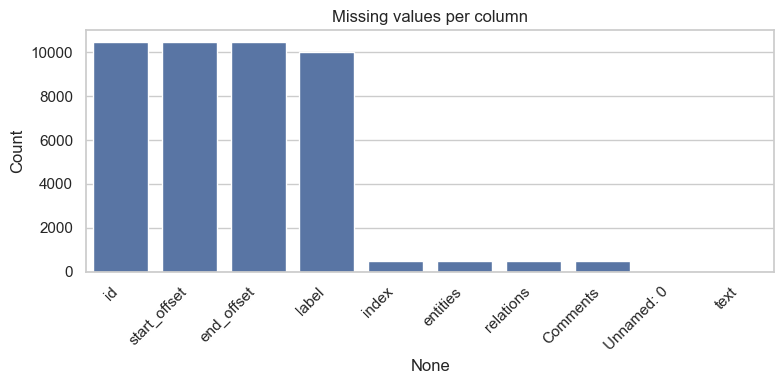


Number of duplicated rows: 74

=== Text length (characters) ===
count    19940.000000
mean       133.910933
std        148.714245
min          3.000000
25%         74.000000
50%        117.000000
75%        166.000000
max       5006.000000
Name: text_char_length, dtype: float64

=== Text length (words) ===
count    19940.000000
mean        19.463490
std         14.205947
min          1.000000
25%         11.000000
50%         18.000000
75%         25.000000
max        490.000000
Name: text_word_count, dtype: float64


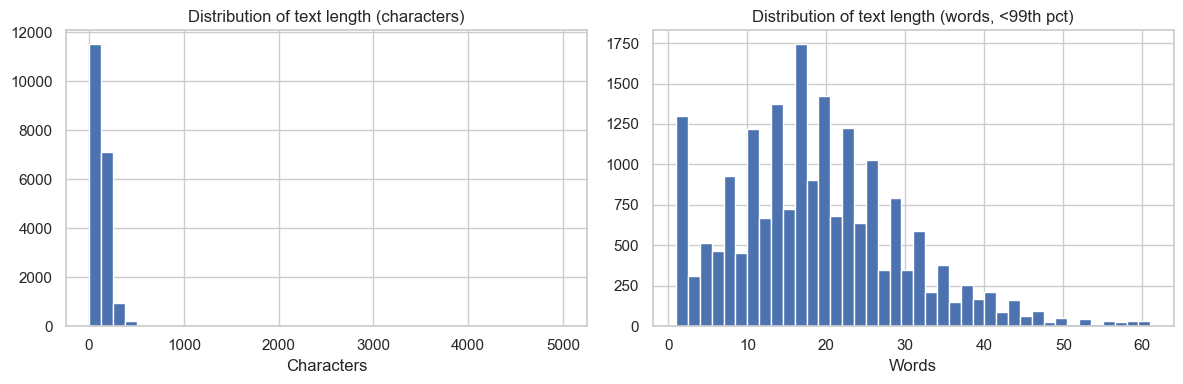


Numeric columns: ['Unnamed: 0', 'index', 'id', 'start_offset', 'end_offset', 'text_char_length', 'text_word_count']


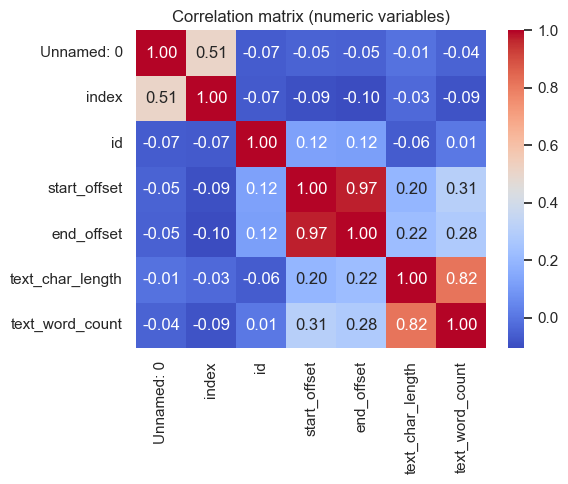


=== Label distribution ===
label
malware           1911
location          1405
SOFTWARE          1229
attack-pattern    1206
identity          1165
threat-actor       890
TIME               475
tools              391
FILEPATH           313
vulnerability      245
SHA2               160
campaign           128
URL                127
IPV4                61
SHA1                60
DOMAIN              50
Infrastucture       43
EMAIL               24
REGISTRYKEY         19
MD5                 16
hash                14
url                  6
Name: count, dtype: int64


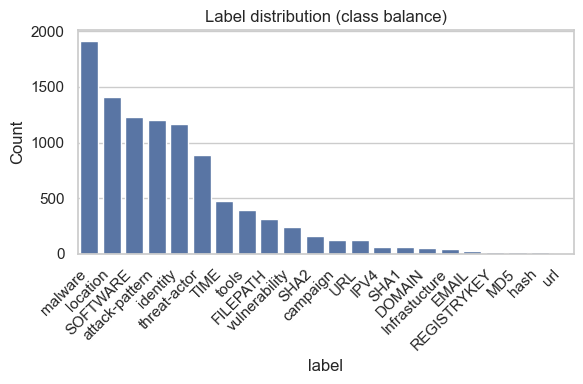

In [6]:
# ============================================================
# 2. Dataset analysis
#    - number of rows/columns
#    - variables definition & types
#    - quality (missing, duplicates)
#    - visualization
#    - correlation analysis
#    - data balance (labels)
# ============================================================

# 2.1 Basic info
print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Column names ===")
print(df.columns.tolist())

print("\n=== Info ===")
print(df.info())

print("\n=== Numeric description ===")
print(df.describe())

print("\n=== Categorical / object description ===")
print(df.describe(include="object"))

# 2.2 Data quality: missing values and duplicates
print("\n=== Missing values per column ===")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45, ha="right")
plt.title("Missing values per column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Number of duplicated rows
dup_count = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {dup_count}")

# 2.3 Simple exploration of key variables


# Text length (helpful for outlier detection later)
if "text" in df.columns:
    df["text_char_length"] = df["text"].astype(str).str.len()
    df["text_word_count"] = df["text"].astype(str).str.split().apply(len)

    print("\n=== Text length (characters) ===")
    print(df["text_char_length"].describe())

    print("\n=== Text length (words) ===")
    print(df["text_word_count"].describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df["text_char_length"], bins=40)
    axes[0].set_title("Distribution of text length (characters)")
    axes[0].set_xlabel("Characters")

    filtered_words = df["text_word_count"][
        df["text_word_count"] < df["text_word_count"].quantile(0.99)
    ]
    axes[1].hist(filtered_words, bins=40)
    axes[1].set_title("Distribution of text length (words, <99th pct)")
    axes[1].set_xlabel("Words")

    plt.tight_layout()
    plt.show()

# 2.4 Correlation analysis (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)

if len(numeric_cols) > 1:
    plt.figure(figsize=(6, 5))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation matrix (numeric variables)")
    plt.tight_layout()
    plt.show()

# 2.5 Data balance (label distribution)
if "label" in df.columns:
    print("\n=== Label distribution ===")
    label_counts = df["label"].value_counts()
    print(label_counts)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_counts.index, y=label_counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Label distribution (class balance)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo 'label' column found for balance analysis.")


In [7]:
# ============================================================
# 3. Data pre-processing
#    - missing values
#    - duplicates
#    - inconsistencies (basic cleaning)
#    - outliers (simple rule on text length)
#    - encoding
#    - scaling
#    - train-test split
# ============================================================

df_clean = df.copy()

# 3.1 Dropping obvious technical columns 
for col in ["Unnamed: 0", "index", "Comments", "relations"]:
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)

print("Columns after dropping technical ones:")
print(df_clean.columns.tolist())

# 3.2 Handle duplicates
# 1: dropping full duplicated rows
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after = df_clean.shape[0]
print(f"\nDropped {before - after} fully duplicated rows.")

#2 dropping duplicates in 'text' only
if "text" in df_clean.columns:
    before = df_clean.shape[0]
    df_clean.drop_duplicates(subset=["text"], inplace=True)
    after = df_clean.shape[0]
    print(f"Dropped {before - after} rows with duplicated 'text'.")

# 3.3 Handle missing values
#  Dropping rows with missing 'text' or 'label' (they are essential)


if "text" in df_clean.columns:
    df_clean = df_clean[df_clean["text"].notna()]

if "label" in df_clean.columns:
    df_clean = df_clean[df_clean["label"].notna()]

print(f"\nShape after removing rows with missing text/label: {df_clean.shape}")

# 3.4 Basic inconsistency cleaning
# - Stripping whitespace from text and labels
if "text" in df_clean.columns:
    df_clean["text"] = df_clean["text"].astype(str).str.strip()

if "label" in df_clean.columns:
    df_clean["label"] = df_clean["label"].astype(str).str.strip()

# 3.5 Outliers (very simple rule on text length)
if "text" in df_clean.columns:
    df_clean["text_word_count"] = df_clean["text"].astype(str).str.split().apply(len)
    q_low = df_clean["text_word_count"].quantile(0.01)
    q_high = df_clean["text_word_count"].quantile(0.99)

    # Keep only texts in [1st, 99th] percentile 
    before = df_clean.shape[0]
    df_clean = df_clean[
        (df_clean["text_word_count"] >= q_low) &
        (df_clean["text_word_count"] <= q_high)
    ]
    after = df_clean.shape[0]
    print(f"\nRemoved {before - after} outlier rows based on text length.")

# 3.6 Encoding (labels)
if "label" in df_clean.columns:
    le = LabelEncoder()
    df_clean["label_encoded"] = le.fit_transform(df_clean["label"])
    print("\nLabel encoding mapping:")
    for cls, enc in zip(le.classes_, le.transform(le.classes_)):
        print(f"{cls} -> {enc}")

# 3.7 Scaling numeric variables
numeric_features = []
for col in ["start_offset", "end_offset", "text_word_count"]:
    if col in df_clean.columns:
        numeric_features.append(col)

print("\nNumeric features to scale:", numeric_features)

scaler = None
if numeric_features:
    scaler = StandardScaler()
    df_clean[numeric_features] = scaler.fit_transform(df_clean[numeric_features])

# 3.8 Train-test split
#   X = raw text + numeric features (if any)
#   y = encoded label

if "label_encoded" in df_clean.columns and "text" in df_clean.columns:
    X_text = df_clean["text"]                # raw text (will be vectorized later)
    X_num = df_clean[numeric_features] if numeric_features else None
    y = df_clean["label_encoded"]


    # Create a simple DataFrame with text + numeric for the split
    if X_num is not None:
        X = pd.concat([X_text, X_num], axis=1)
    else:
        X = X_text.to_frame(name="text")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("\nTrain-test split done.")
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train distribution:")
    display(pd.Series(y_train).value_counts(normalize=True))

else:
    print("\nCannot do train-test split because 'text' or 'label_encoded' is missing.")

print("\nPre-processing finished.")


Columns after dropping technical ones:
['text', 'entities', 'id', 'label', 'start_offset', 'end_offset', 'text_char_length', 'text_word_count']

Dropped 10671 fully duplicated rows.
Dropped 1001 rows with duplicated 'text'.

Shape after removing rows with missing text/label: (4186, 8)

Removed 40 outlier rows based on text length.

Label encoding mapping:
DOMAIN -> 0
EMAIL -> 1
FILEPATH -> 2
IPV4 -> 3
Infrastucture -> 4
MD5 -> 5
REGISTRYKEY -> 6
SHA1 -> 7
SHA2 -> 8
SOFTWARE -> 9
TIME -> 10
URL -> 11
attack-pattern -> 12
campaign -> 13
hash -> 14
identity -> 15
location -> 16
malware -> 17
threat-actor -> 18
tools -> 19
vulnerability -> 20

Numeric features to scale: ['start_offset', 'end_offset', 'text_word_count']

Train-test split done.
X_train shape: (3316, 4)
X_test shape: (830, 4)
y_train distribution:


label_encoded
17    0.198130
9     0.136610
15    0.120627
16    0.117913
12    0.115802
18    0.086248
10    0.053679
19    0.039204
2     0.034680
20    0.026538
8     0.018094
13    0.012666
11    0.010856
7     0.006634
0     0.006031
3     0.005428
4     0.004222
1     0.002111
6     0.002111
5     0.001809
14    0.000603
Name: proportion, dtype: float64


Pre-processing finished.


In [8]:
# Save cleaned dataframe to CSV
output_path = "cyber-threat-intelligence_clean.csv"
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved as: {output_path}")


Cleaned dataset saved as: cyber-threat-intelligence_clean.csv
